# Madrid Master Dataset EDA

## 1. Setup and Imports

In [1]:
from pathlib import Path
import warnings

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

try:
    import geopandas as gpd
    HAS_GEOPANDAS = True
except ImportError:
    HAS_GEOPANDAS = False

CITY = "Madrid"
CITY_KEY = "madrid"
CITY_COLOR = "#1f77b4"

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 110


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "1. Data" / "master").exists():
            return candidate
    raise FileNotFoundError("Could not find the CAPSTONE folder containing '1. Data/master'.")


ROOT = find_project_root()
DATA_DIR = ROOT / "1. Data"
MASTER_DIR = DATA_DIR / "master"
RAW_DIR = DATA_DIR / "raw"
GEO_DIR = RAW_DIR / "geodata"
OUTPUT_DIR = DATA_DIR / "Outputs" / "eda"


def available_columns(frame: pd.DataFrame, columns: list[str]) -> list[str]:
    return [column for column in columns if column in frame.columns]


def first_existing_column(frame: pd.DataFrame, columns: list[str]) -> str | None:
    matches = available_columns(frame, columns)
    return matches[0] if matches else None


def as_numeric(frame: pd.DataFrame, column: str) -> pd.Series:
    if column not in frame.columns:
        return pd.Series(dtype="float64")
    return pd.to_numeric(frame[column], errors="coerce")


def format_eur(value) -> str:
    if pd.isna(value):
        return "n/a"
    return f"EUR {value:,.0f}"


print(f"Using CAPSTONE root: {ROOT}")
print(f"Selected city: {CITY}")

Using CAPSTONE root: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE
Selected city: Madrid


## 2. Load the Master Dataset

In [2]:
data_path = MASTER_DIR / f"{CITY_KEY}_master_model_dataset.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Master dataset not found: {data_path}")

df = pd.read_csv(data_path)

print(f"{CITY} master dataset shape: {df.shape[0]:,} rows and {df.shape[1]:,} columns")
display(df.head())

Madrid master dataset shape: 17,770 rows and 88 columns


,listing_id,city,price_eur,log_price_eur,neighbourhood_cleansed,neighbourhood_group,latitude,longitude,distance_to_center_km,is_central_5km,...,calendar_unavailable_q3,calendar_unavailable_q4,calendar_unavailable_autumn,calendar_unavailable_spring,calendar_unavailable_summer,calendar_unavailable_winter,calendar_unavailable_weekday,calendar_unavailable_weekend,raw_review_total_reviews,raw_reviews_last_6m
0,30320,Madrid,157.0,5.062595,Sol,Centro,40.41476,-3.70418,0.2291,1,...,0.152174,0.065217,0.153846,0.000000,0.0,0.100000,0.061303,0.067308,173.0,1.0
1,40916,Madrid,143.0,4.969813,Universidad,Centro,40.42247,-3.70577,0.6522,1,...,0.173913,0.086957,0.252747,0.000000,0.0,0.011111,0.065134,0.067308,53.0,4.0
2,62423,Madrid,65.0,4.189655,Justicia,Centro,40.41884,-3.69655,0.6543,1,...,0.152174,0.510870,0.615385,0.054348,0.0,0.055556,0.172414,0.201923,249.0,21.0
3,70073,Madrid,116.0,4.762174,Universidad,Centro,40.42252,-3.70250,0.6455,1,...,0.141304,0.510870,0.659341,0.000000,0.0,0.000000,0.160920,0.173077,36.0,1.0
4,70310,Madrid,79.0,4.382027,Universidad,Centro,40.42252,-3.70250,0.6455,1,...,0.173913,0.347826,0.527473,0.000000,0.0,0.000000,0.134100,0.125000,31.0,2.0


This loads the city master modelling dataset from `1. Data/master` and previews the first rows so we can confirm the file opened correctly.

## 3. Dataset Overview

In [3]:
summary_rows = [
    ("Rows", f"{len(df):,}"),
    ("Columns", f"{df.shape[1]:,}"),
    ("Neighbourhoods", f"{df['neighbourhood_cleansed'].nunique():,}" if "neighbourhood_cleansed" in df.columns else "n/a"),
    ("Room types", f"{df['room_type'].nunique():,}" if "room_type" in df.columns else "n/a"),
    ("Median nightly price", format_eur(as_numeric(df, "price_eur").median())),
    ("Mean rating", f"{as_numeric(df, 'review_scores_rating').mean():.2f}" if "review_scores_rating" in df.columns else "n/a"),
    ("Median availability next 30 days", f"{as_numeric(df, 'availability_30').median():.0f}" if "availability_30" in df.columns else "n/a"),
]

overview = pd.DataFrame(summary_rows, columns=["Metric", "Value"])
display(overview)

dtypes = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="column_count")
)
display(dtypes)

,Metric,Value
0,Rows,"17,770"
1,Columns,88
2,Neighbourhoods,128
3,Room types,4
4,Median nightly price,EUR 105
5,Mean rating,4.63
6,Median availability next 30 days,6


,dtype,column_count
0,float64,41
1,int64,35
2,object,12


This summarises the dataset size, key city-level counts, pricing, ratings, availability, and the data types present in the master dataset.

## 4. Missing Values

,missing_pct
raw_review_total_reviews,15.9
review_scores_communication,15.9
review_scores_location,15.9
last_review,15.9
first_review,15.9
review_scores_rating,15.9
review_scores_accuracy,15.9
review_scores_cleanliness,15.9
days_since_last_review,15.9
review_history_days,15.9


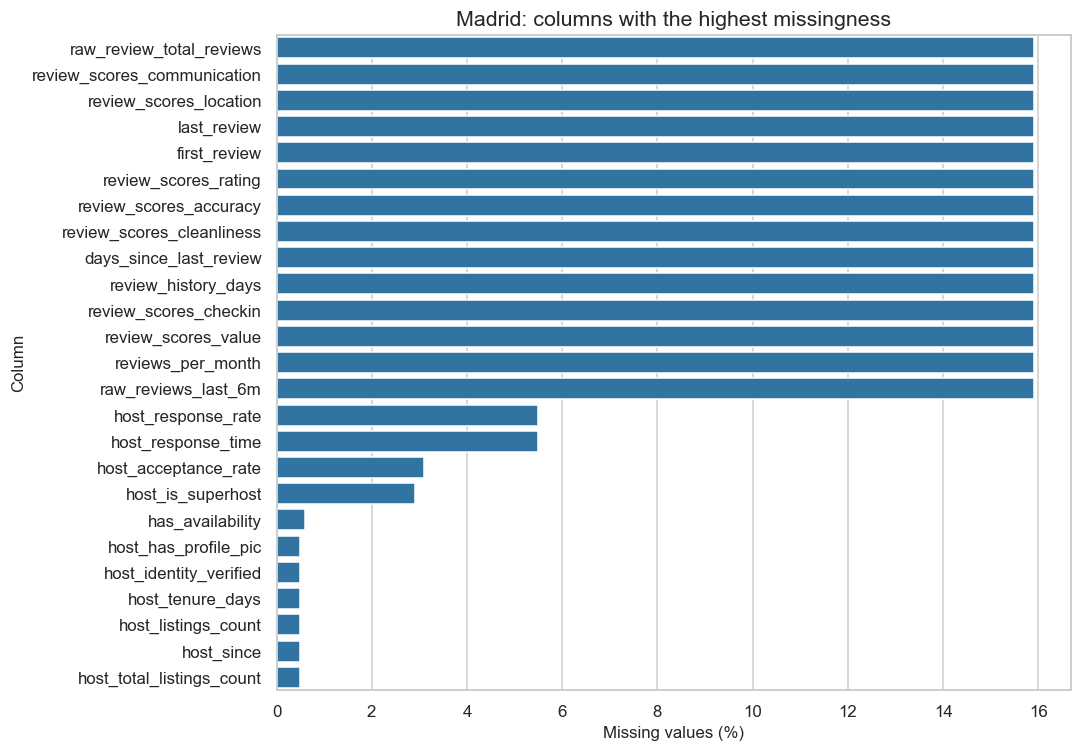

In [4]:
missing = (
    df.isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
)
missing_display = missing[missing > 0].head(25).rename("missing_pct").to_frame()

display(missing_display)

if missing_display.empty:
    print("No missing values were found in the master dataset.")
else:
    plt.figure(figsize=(10, max(5, len(missing_display) * 0.28)))
    sns.barplot(
        x="missing_pct",
        y=missing_display.index,
        data=missing_display.reset_index(names="column"),
        color=CITY_COLOR,
    )
    plt.title(f"{CITY}: columns with the highest missingness")
    plt.xlabel("Missing values (%)")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()

Columns with high "missingness" will need handling before model prep

## 5. Price Distribution

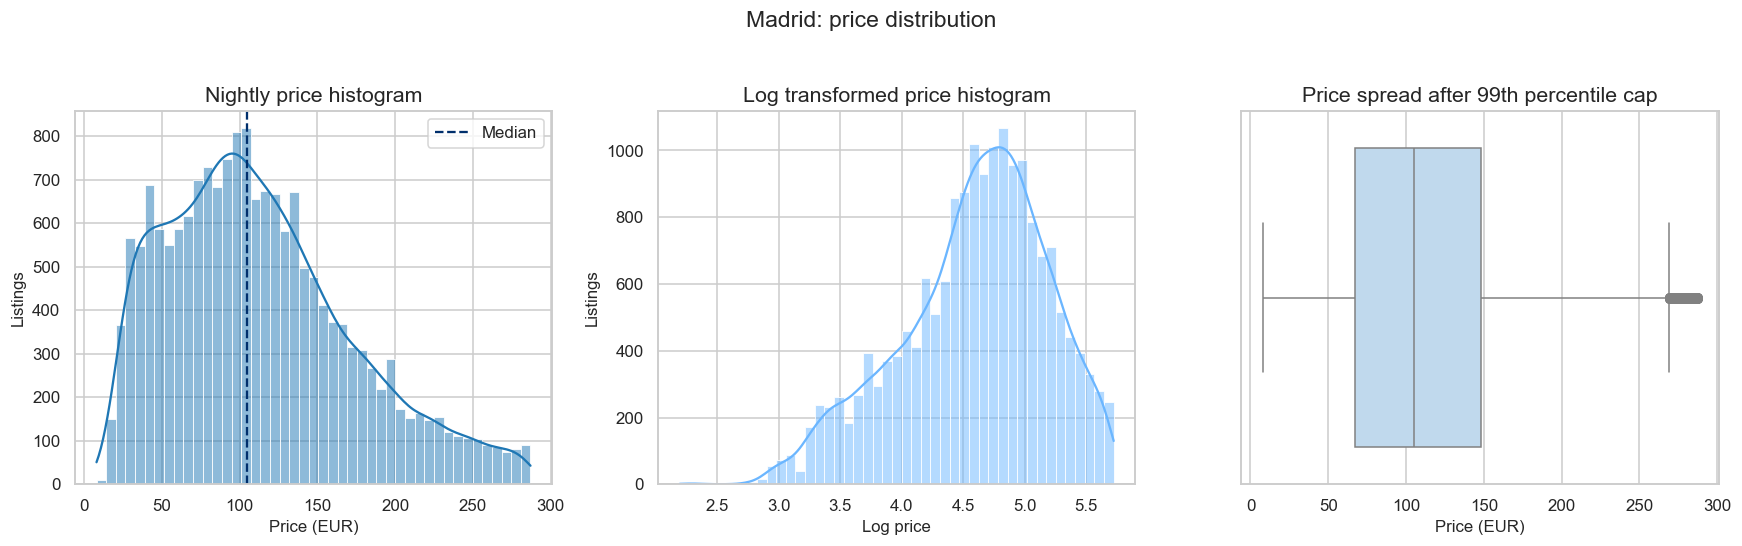

,count,mean,std,min,5%,25%,50%,75%,95%,max
price_eur,17770.0,114.6,62.3,8.0,30.0,67.0,105.0,150.0,239.0,305.0


Median nightly price: EUR 105
Mean nightly price: EUR 115
95th percentile nightly price: EUR 239


In [5]:
price = as_numeric(df, "price_eur").dropna()
price_summary = price.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame("price_eur").T.round(2)

price_cap = price.quantile(0.99)
plot_price = price[price <= price_cap]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

sns.histplot(plot_price, bins=45, kde=True, color=CITY_COLOR, ax=axes[0])
axes[0].axvline(price.median(), color="#002f6c", linestyle="--", label="Median")
axes[0].set_title("Nightly price histogram")
axes[0].set_xlabel("Price (EUR)")
axes[0].set_ylabel("Listings")
axes[0].legend()

if "log_price_eur" in df.columns:
    sns.histplot(as_numeric(df, "log_price_eur").dropna(), bins=45, kde=True, color="#6bb6ff", ax=axes[1])
    axes[1].set_xlabel("Log price")
else:
    sns.histplot(np.log1p(price), bins=45, kde=True, color="#6bb6ff", ax=axes[1])
    axes[1].set_xlabel("Log price")
axes[1].set_title("Log transformed price histogram")
axes[1].set_ylabel("Listings")

sns.boxplot(x=plot_price, color="#b8daf5", ax=axes[2])
axes[2].set_title("Price spread after 99th percentile cap")
axes[2].set_xlabel("Price (EUR)")

plt.suptitle(f"{CITY}: price distribution", y=1.03, fontsize=15)
plt.tight_layout()
plt.show()

display(price_summary)
print(f"Median nightly price: {format_eur(price.median())}")
print(f"Mean nightly price: {format_eur(price.mean())}")
print(f"95th percentile nightly price: {format_eur(price.quantile(0.95))}")

This cell uses a histogram to show the shape of nightly prices, includes the log-price view for skew, adds a boxplot for spread, and then prints the key price statistics.

## 6. Property Type and Capacity

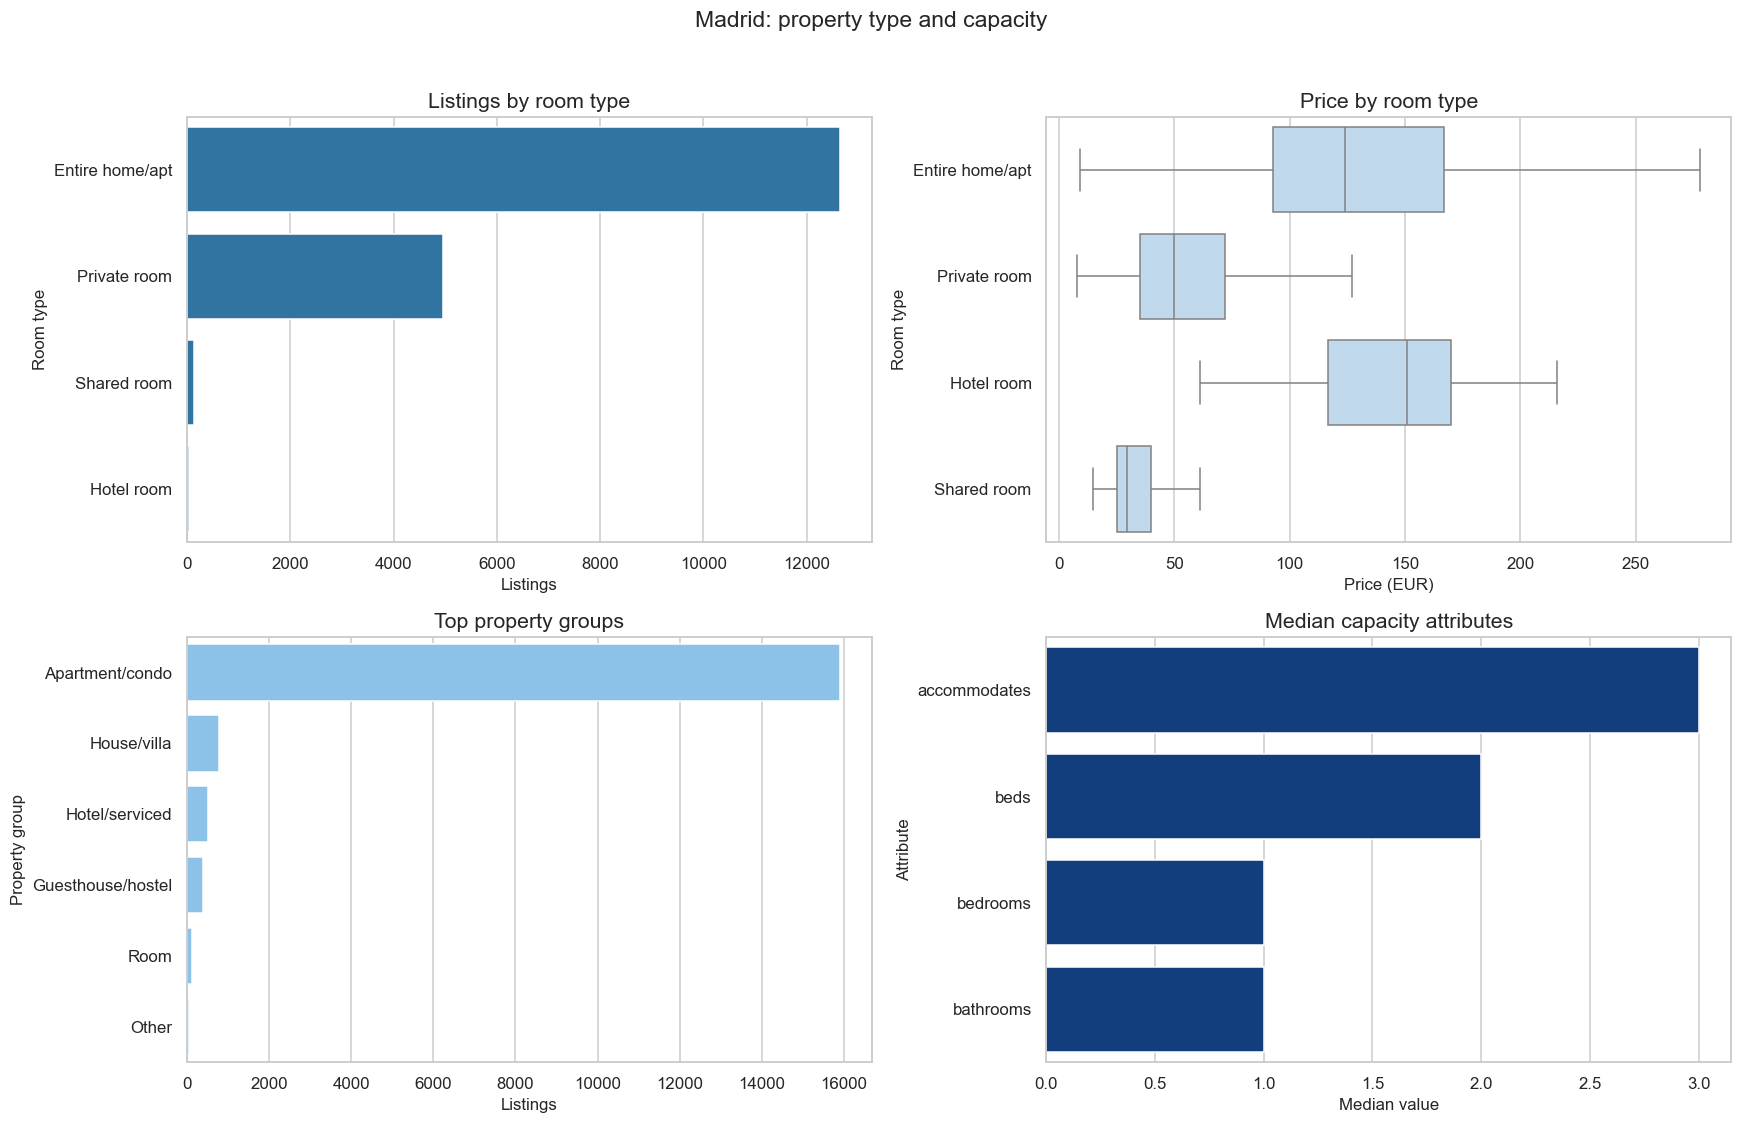

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if "room_type" in df.columns:
    order = df["room_type"].value_counts().index
    sns.countplot(data=df, y="room_type", order=order, color=CITY_COLOR, ax=axes[0, 0])
    axes[0, 0].set_title("Listings by room type")
    axes[0, 0].set_xlabel("Listings")
    axes[0, 0].set_ylabel("Room type")
else:
    axes[0, 0].axis("off")

if {"room_type", "price_eur"}.issubset(df.columns):
    sns.boxplot(data=df, x="price_eur", y="room_type", showfliers=False, color="#b8daf5", ax=axes[0, 1])
    axes[0, 1].set_title("Price by room type")
    axes[0, 1].set_xlabel("Price (EUR)")
    axes[0, 1].set_ylabel("Room type")
else:
    axes[0, 1].axis("off")

if "property_group" in df.columns:
    property_counts = df["property_group"].value_counts().head(10)
    sns.barplot(x=property_counts.values, y=property_counts.index, color="#7cc4f8", ax=axes[1, 0])
    axes[1, 0].set_title("Top property groups")
    axes[1, 0].set_xlabel("Listings")
    axes[1, 0].set_ylabel("Property group")
else:
    axes[1, 0].axis("off")

capacity_cols = available_columns(df, ["accommodates", "bedrooms", "bathrooms", "beds"])
if capacity_cols:
    capacity = df[capacity_cols].apply(pd.to_numeric, errors="coerce").median().sort_values(ascending=False)
    sns.barplot(x=capacity.values, y=capacity.index, color="#003b8f", ax=axes[1, 1])
    axes[1, 1].set_title("Median capacity attributes")
    axes[1, 1].set_xlabel("Median value")
    axes[1, 1].set_ylabel("Attribute")
else:
    axes[1, 1].axis("off")

plt.suptitle(f"{CITY}: property type and capacity", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

This section compares room types, property groups, and capacity attributes such as bedrooms, beds, bathrooms, and accommodates.

## 7. Location and Neighbourhoods

,neighbourhood_cleansed,listings,median_price_eur,mean_price_eur,mean_rating,median_distance_km,median_availability_30
50,Embajadores,1878,105.0,116.25,4.62,0.81,5.0
117,Universidad,1566,118.0,124.85,4.61,0.80,4.0
83,Palacio,1354,129.0,138.62,4.67,0.74,5.0
114,Sol,994,141.0,146.90,4.61,0.26,4.0
65,Justicia,861,130.0,138.96,4.62,0.82,4.0
40,Cortes,758,133.5,140.36,4.64,0.54,4.0
42,Cuatro Caminos,343,109.0,109.70,4.65,3.86,9.0
116,Trafalgar,330,135.0,137.56,4.61,1.66,3.0
87,Palos de Moguer,292,103.0,112.82,4.68,1.63,6.0
58,Guindalera,284,110.0,121.18,4.60,3.51,5.0


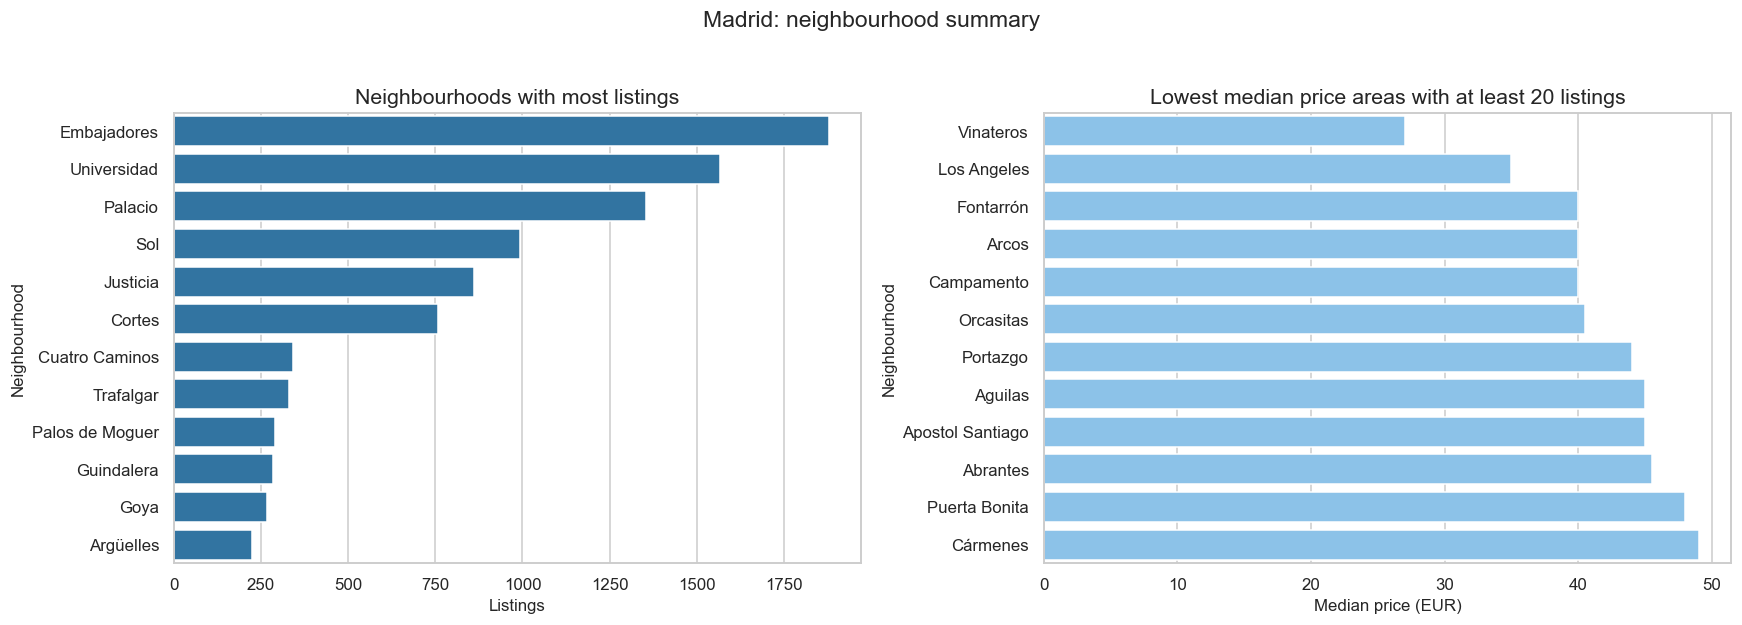

In [7]:
if "neighbourhood_cleansed" not in df.columns:
    raise ValueError("Expected neighbourhood_cleansed in the master dataset.")

neighbourhood_summary = (
    df.groupby("neighbourhood_cleansed")
    .agg(
        listings=("listing_id", "count") if "listing_id" in df.columns else ("city", "count"),
        median_price_eur=("price_eur", "median"),
        mean_price_eur=("price_eur", "mean"),
        mean_rating=("review_scores_rating", "mean"),
        median_distance_km=("distance_to_center_km", "median"),
        median_availability_30=("availability_30", "median"),
    )
    .reset_index()
    .sort_values("listings", ascending=False)
)

for column in ["median_price_eur", "mean_price_eur", "mean_rating", "median_distance_km", "median_availability_30"]:
    if column in neighbourhood_summary.columns:
        neighbourhood_summary[column] = neighbourhood_summary[column].round(2)

display(neighbourhood_summary.head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

top_listing_areas = neighbourhood_summary.head(12)
sns.barplot(data=top_listing_areas, x="listings", y="neighbourhood_cleansed", color=CITY_COLOR, ax=axes[0])
axes[0].set_title("Neighbourhoods with most listings")
axes[0].set_xlabel("Listings")
axes[0].set_ylabel("Neighbourhood")

price_areas = neighbourhood_summary[neighbourhood_summary["listings"] >= 20].nsmallest(12, "median_price_eur")
sns.barplot(data=price_areas, x="median_price_eur", y="neighbourhood_cleansed", color="#7cc4f8", ax=axes[1])
axes[1].set_title("Lowest median price areas with at least 20 listings")
axes[1].set_xlabel("Median price (EUR)")
axes[1].set_ylabel("Neighbourhood")

plt.suptitle(f"{CITY}: neighbourhood summary", y=1.03, fontsize=15)
plt.tight_layout()
plt.show()

This groups listings by neighbourhood to compare supply, median price, rating, availability, and distance to the city centre.

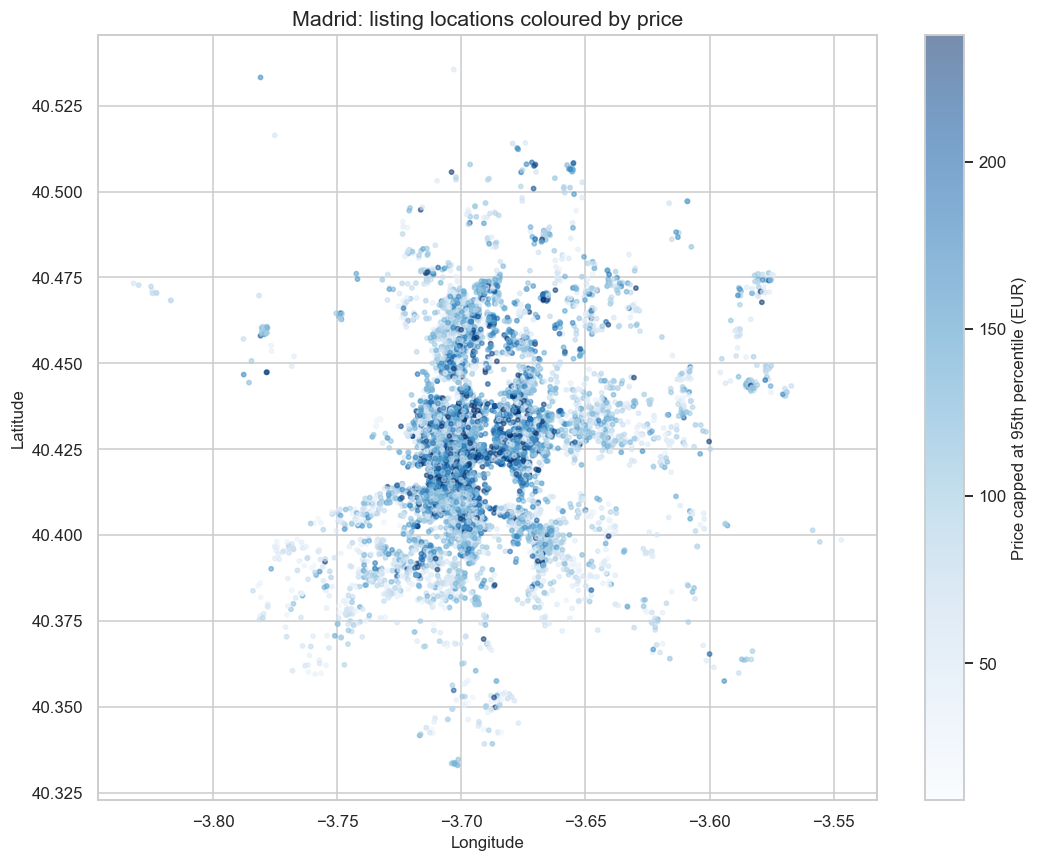

In [8]:
required = {"latitude", "longitude", "price_eur"}
if required.issubset(df.columns):
    map_sample = df.dropna(subset=["latitude", "longitude", "price_eur"]).copy()
    if len(map_sample) > 10000:
        map_sample = map_sample.sample(10000, random_state=42)

    price_cap = map_sample["price_eur"].quantile(0.95)
    map_sample["price_for_colour"] = map_sample["price_eur"].clip(upper=price_cap)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        map_sample["longitude"],
        map_sample["latitude"],
        c=map_sample["price_for_colour"],
        cmap="Blues",
        s=8,
        alpha=0.55,
    )
    plt.colorbar(scatter, label="Price capped at 95th percentile (EUR)")
    plt.title(f"{CITY}: listing locations coloured by price")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()
else:
    print("Latitude, longitude, or price columns are not available for the map scatter plot.")

This scatter plot uses latitude and longitude to show how listings are distributed geographically and how price varies across space.

Map cropped to the central listing coordinate range so distant outlying polygons do not squash the main city view.


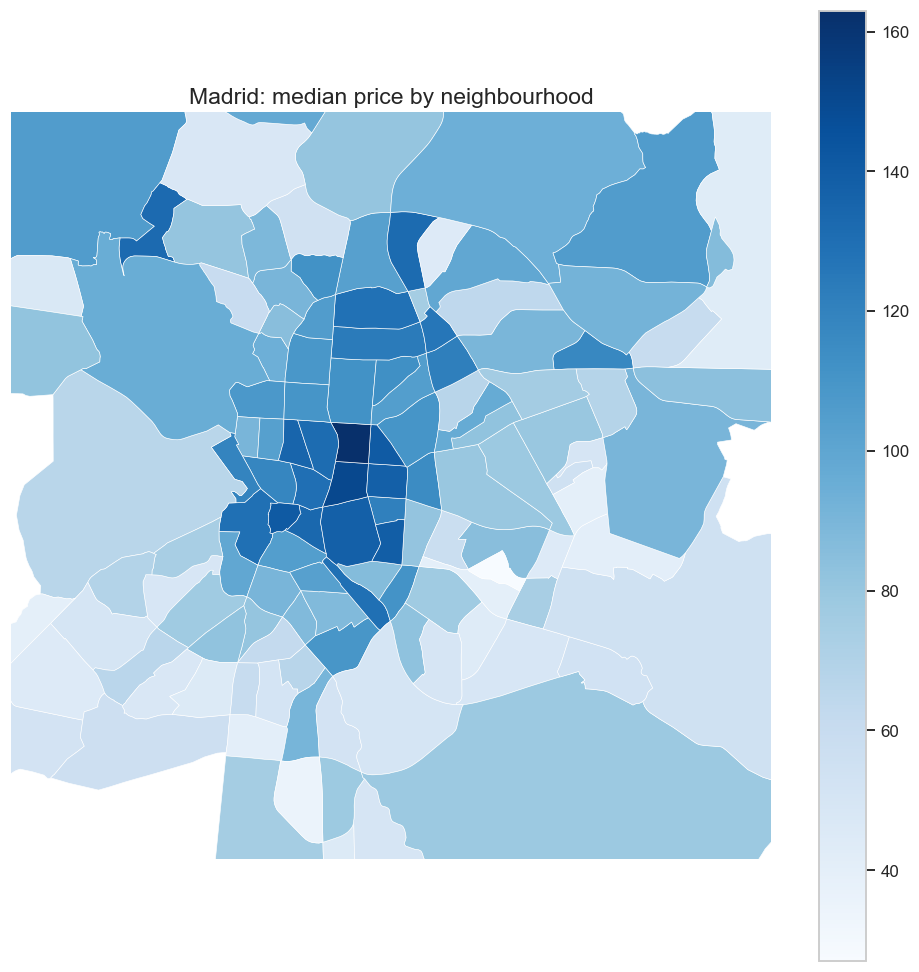

In [9]:
geo_path = GEO_DIR / f"{CITY_KEY}_neighbourhoods.geojson"

if not HAS_GEOPANDAS:
    print("Geopandas is not installed in this environment, so the optional neighbourhood map is skipped.")
elif not geo_path.exists():
    print(f"Neighbourhood GeoJSON not found: {geo_path}")
elif "neighbourhood_cleansed" not in df.columns:
    print("neighbourhood_cleansed is missing, so the optional neighbourhood map is skipped.")
else:
    gdf = gpd.read_file(geo_path)
    geo_key = first_existing_column(gdf, ["neighbourhood", "neighbourhood_cleansed", "name", "neighbourhood_group"])

    if geo_key is None:
        print("No matching neighbourhood name column was found in the GeoJSON.")
    else:
        neighbourhood_prices = (
            df.groupby("neighbourhood_cleansed")
            .agg(listings=("price_eur", "size"), median_price_eur=("price_eur", "median"))
            .reset_index()
        )
        mapped = gdf.merge(neighbourhood_prices, left_on=geo_key, right_on="neighbourhood_cleansed", how="left")

        fig, ax = plt.subplots(figsize=(9, 9))
        mapped.plot(
            column="median_price_eur",
            cmap="Blues",
            linewidth=0.4,
            edgecolor="white",
            legend=True,
            missing_kwds={"color": "#f2f6fb", "label": "No data"},
            ax=ax,
        )

        if {"latitude", "longitude"}.issubset(df.columns):
            coords = df[["latitude", "longitude"]].dropna().apply(pd.to_numeric, errors="coerce").dropna()
            if not coords.empty:
                lon_min, lon_max = coords["longitude"].quantile([0.01, 0.99])
                lat_min, lat_max = coords["latitude"].quantile([0.01, 0.99])
                lon_pad = max((lon_max - lon_min) * 0.12, 0.02)
                lat_pad = max((lat_max - lat_min) * 0.12, 0.02)
                ax.set_xlim(lon_min - lon_pad, lon_max + lon_pad)
                ax.set_ylim(lat_min - lat_pad, lat_max + lat_pad)
                print("Map cropped to the central listing coordinate range so distant outlying polygons do not squash the main city view.")

        ax.set_axis_off()
        ax.set_title(f"{CITY}: median price by neighbourhood", fontsize=15)
        plt.tight_layout()
        plt.show()

If the local GeoJSON and geopandas are available, this optional map shades neighbourhoods by their median nightly price. The view is cropped to the central listing area so Tokyo's distant island polygons do not shrink the main map.

## 8. Host and Booking Behaviour

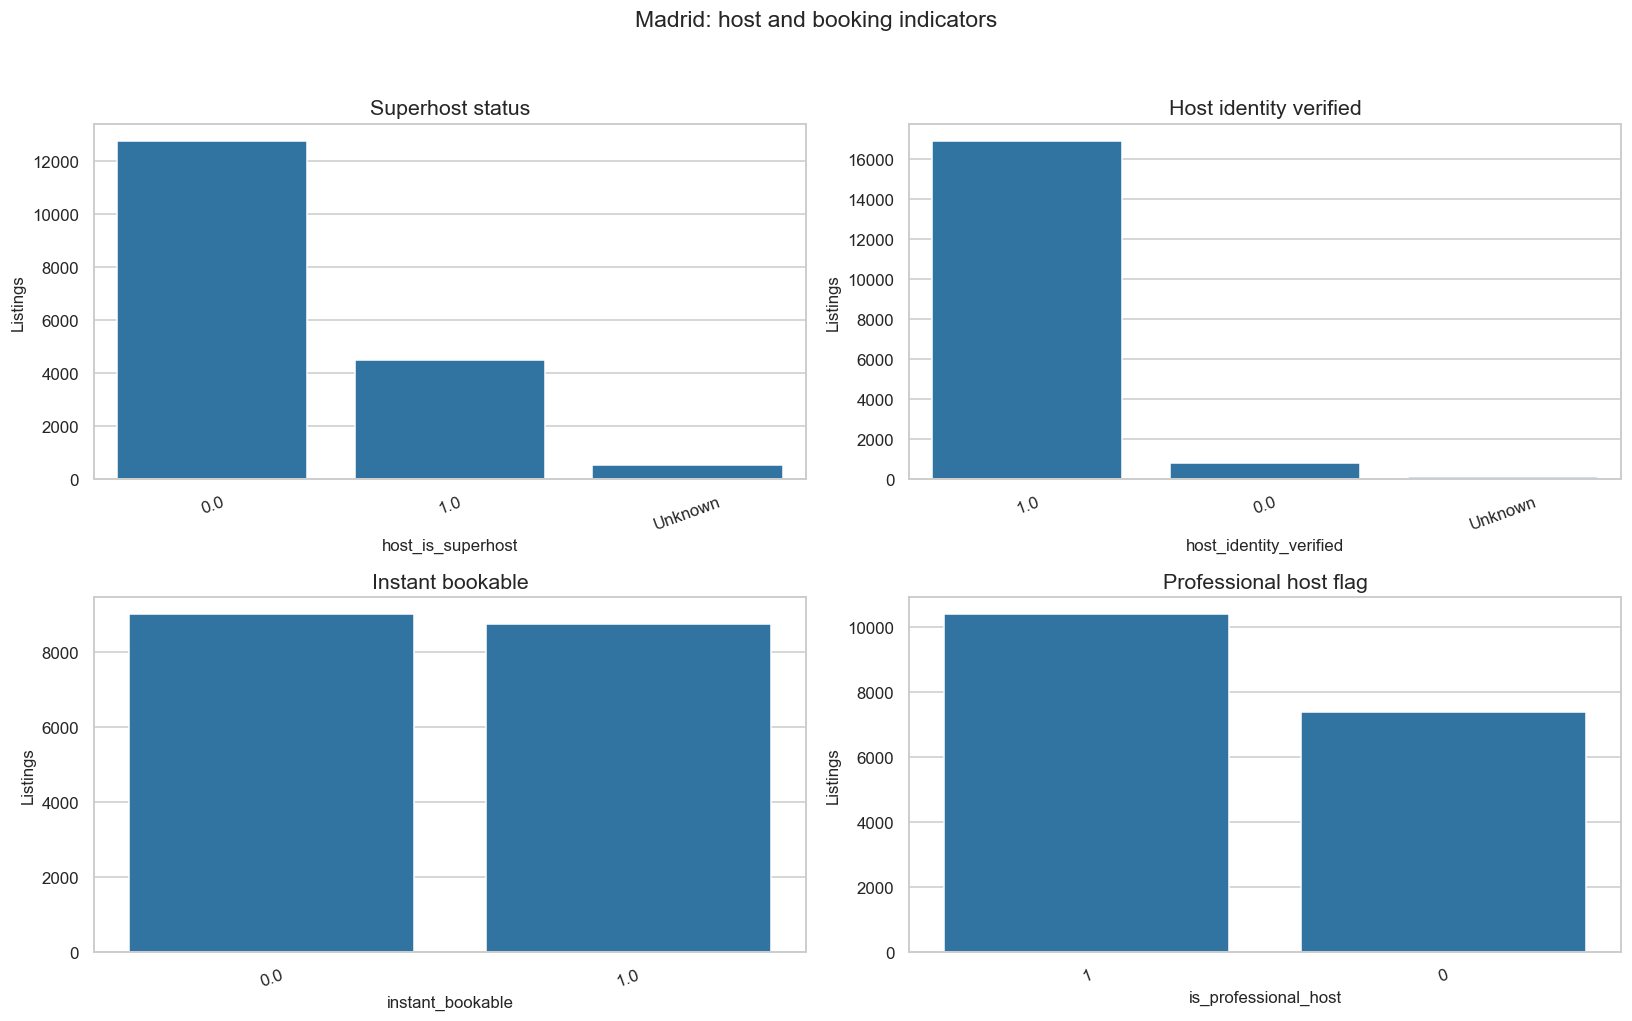

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
host_response_time,16794,4,within an hour,12309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_response_rate,16794.0,NaN,NaN,NaN,0.90341,0.223995,0.0,0.95,1.0,1.0,1.0
host_acceptance_rate,17216.0,NaN,NaN,NaN,0.848053,0.269764,0.0,0.86,0.99,1.0,1.0
host_listings_count,17682.0,NaN,NaN,NaN,71.185782,161.788458,1.0,2.0,7.0,44.0,1192.0
host_tenure_days,17682.0,NaN,NaN,NaN,2234.006504,1403.249661,3.0,1007.0,2125.5,3425.0,5965.0


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

binary_columns = [
    ("host_is_superhost", "Superhost status"),
    ("host_identity_verified", "Host identity verified"),
    ("instant_bookable", "Instant bookable"),
    ("is_professional_host", "Professional host flag"),
]

for ax, (column, title) in zip(axes.flat, binary_columns):
    if column in df.columns:
        counts = df[column].fillna("Unknown").astype(str).value_counts()
        sns.barplot(x=counts.index, y=counts.values, color=CITY_COLOR, ax=ax)
        ax.set_title(title)
        ax.set_xlabel(column)
        ax.set_ylabel("Listings")
        ax.tick_params(axis="x", rotation=20)
    else:
        ax.axis("off")

plt.suptitle(f"{CITY}: host and booking indicators", y=1.03, fontsize=15)
plt.tight_layout()
plt.show()

host_cols = available_columns(df, ["host_response_time", "host_response_rate", "host_acceptance_rate", "host_listings_count", "host_tenure_days"])
if host_cols:
    display(df[host_cols].describe(include="all").T)
else:
    print("No host behaviour columns were available for summary.")

This looks at host-related indicators, including superhost status, verification, instant booking, and professional host flags.

## 9. Availability and Calendar Features

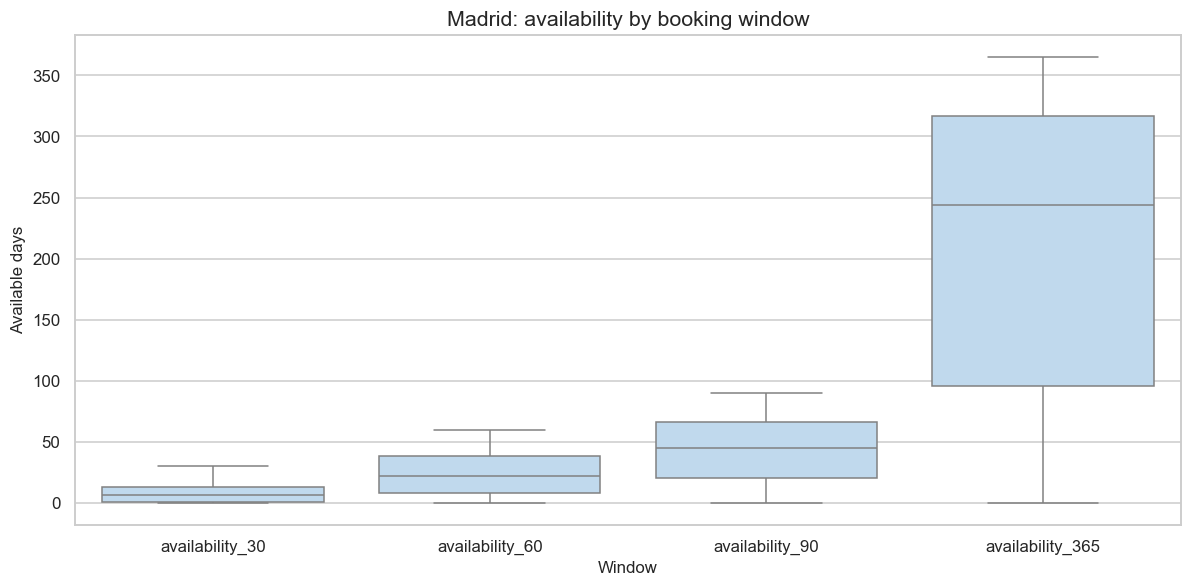

,mean_unavailable_rate
calendar_unavailable_autumn,0.540
calendar_unavailable_summer,0.445
calendar_unavailable_weekend,0.428
calendar_unavailable_rate,0.419
calendar_unavailable_weekday,0.415
calendar_unavailable_spring,0.358
calendar_unavailable_winter,0.332


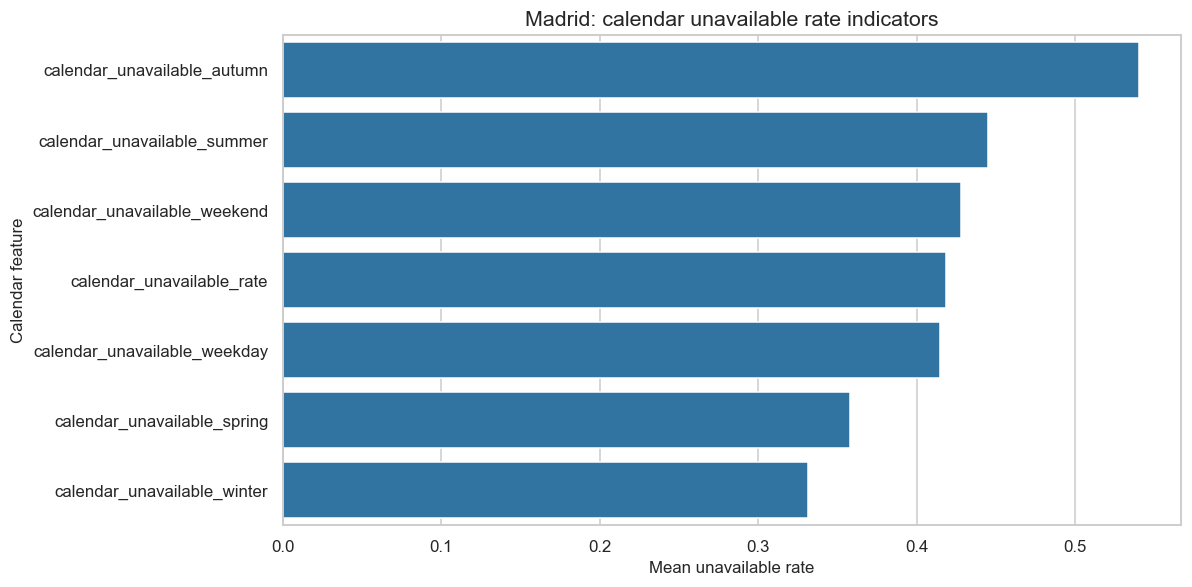

In [11]:
availability_cols = available_columns(df, ["availability_30", "availability_60", "availability_90", "availability_365"])
calendar_cols = available_columns(
    df,
    [
        "calendar_unavailable_rate",
        "calendar_unavailable_weekday",
        "calendar_unavailable_weekend",
        "calendar_unavailable_winter",
        "calendar_unavailable_spring",
        "calendar_unavailable_summer",
        "calendar_unavailable_autumn",
    ],
)

if availability_cols:
    availability_long = df[availability_cols].apply(pd.to_numeric, errors="coerce").melt(var_name="Availability window", value_name="Available days")
    plt.figure(figsize=(11, 5.5))
    sns.boxplot(data=availability_long, x="Availability window", y="Available days", color="#b8daf5", showfliers=False)
    plt.title(f"{CITY}: availability by booking window")
    plt.xlabel("Window")
    plt.ylabel("Available days")
    plt.tight_layout()
    plt.show()
else:
    print("Availability window columns were not found.")

if calendar_cols:
    calendar_means = df[calendar_cols].apply(pd.to_numeric, errors="coerce").mean().sort_values(ascending=False)
    display(calendar_means.rename("mean_unavailable_rate").round(3).to_frame())

    plt.figure(figsize=(11, 5.5))
    sns.barplot(x=calendar_means.values, y=calendar_means.index, color=CITY_COLOR)
    plt.title(f"{CITY}: calendar unavailable rate indicators")
    plt.xlabel("Mean unavailable rate")
    plt.ylabel("Calendar feature")
    plt.tight_layout()
    plt.show()
else:
    print("Calendar availability columns were not found.")

This checks the availability windows and calendar-derived unavailable-rate features that may be useful for the chatbot and market interpretation.

## 10. Amenities

,listings_with_amenity_pct
has_wifi,97.6
has_kitchen,90.2
has_tv,86.6
has_washer,84.7
has_heating,79.7
has_air_conditioning,78.6
has_dedicated_workspace,53.2
has_elevator,42.7
has_parking,39.8
has_self_checkin,32.3


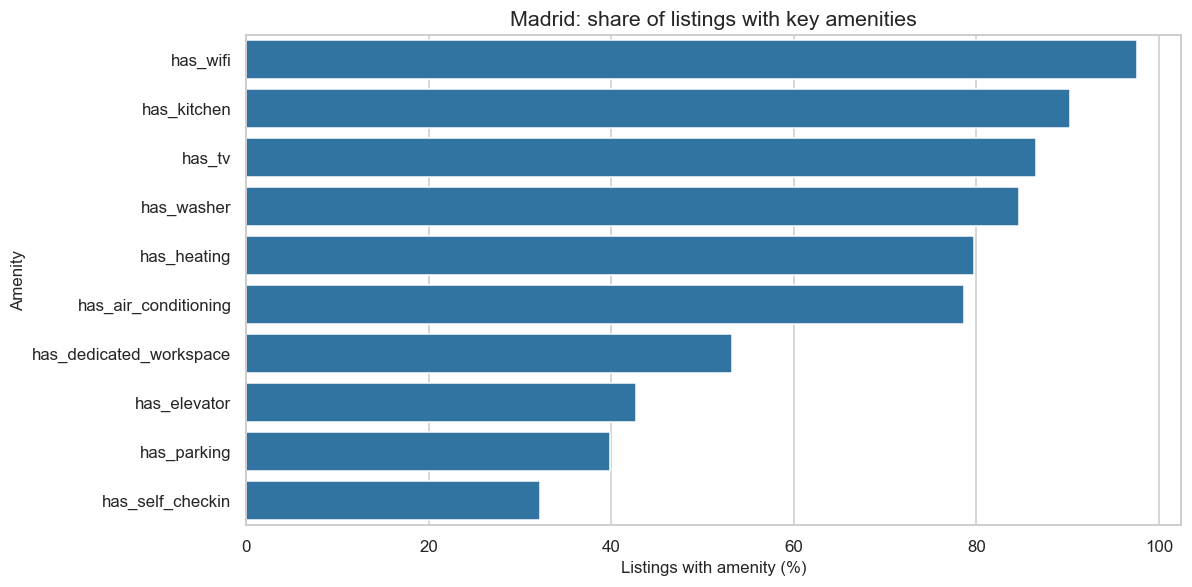

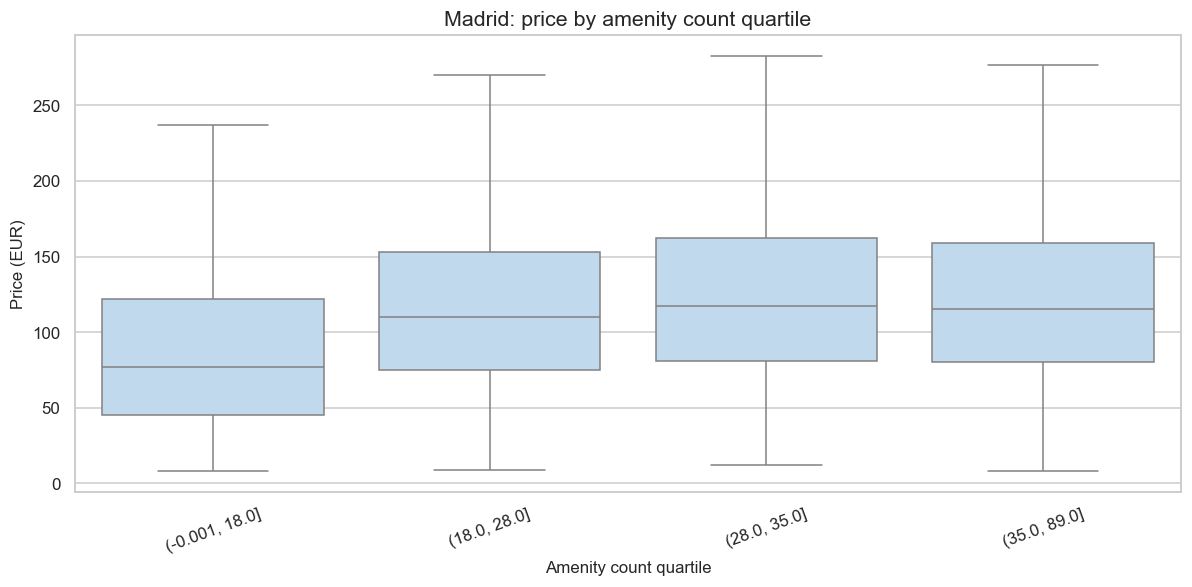

In [12]:
amenity_cols = available_columns(
    df,
    [
        "has_wifi",
        "has_kitchen",
        "has_air_conditioning",
        "has_washer",
        "has_dedicated_workspace",
        "has_tv",
        "has_parking",
        "has_elevator",
        "has_heating",
        "has_self_checkin",
    ],
)

if amenity_cols:
    amenity_rates = df[amenity_cols].apply(pd.to_numeric, errors="coerce").mean().mul(100).sort_values(ascending=False)
    display(amenity_rates.rename("listings_with_amenity_pct").round(1).to_frame())

    plt.figure(figsize=(11, 5.5))
    sns.barplot(x=amenity_rates.values, y=amenity_rates.index, color=CITY_COLOR)
    plt.title(f"{CITY}: share of listings with key amenities")
    plt.xlabel("Listings with amenity (%)")
    plt.ylabel("Amenity")
    plt.tight_layout()
    plt.show()
else:
    print("Amenity indicator columns were not found.")

if {"amenities_count", "price_eur"}.issubset(df.columns):
    amenity_price = df[["amenities_count", "price_eur"]].copy()
    amenity_price["amenities_count"] = pd.to_numeric(amenity_price["amenities_count"], errors="coerce")
    amenity_price["price_eur"] = pd.to_numeric(amenity_price["price_eur"], errors="coerce")
    amenity_price = amenity_price.dropna()
    amenity_price["amenity_band"] = pd.qcut(amenity_price["amenities_count"], q=4, duplicates="drop")

    plt.figure(figsize=(11, 5.5))
    sns.boxplot(data=amenity_price, x="amenity_band", y="price_eur", color="#b8daf5", showfliers=False)
    plt.title(f"{CITY}: price by amenity count quartile")
    plt.xlabel("Amenity count quartile")
    plt.ylabel("Price (EUR)")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
else:
    print("Amenities count or price columns were not found.")

This compares key amenity indicators and checks how the number of amenities relates to nightly price.

## 11. Reviews and Ratings

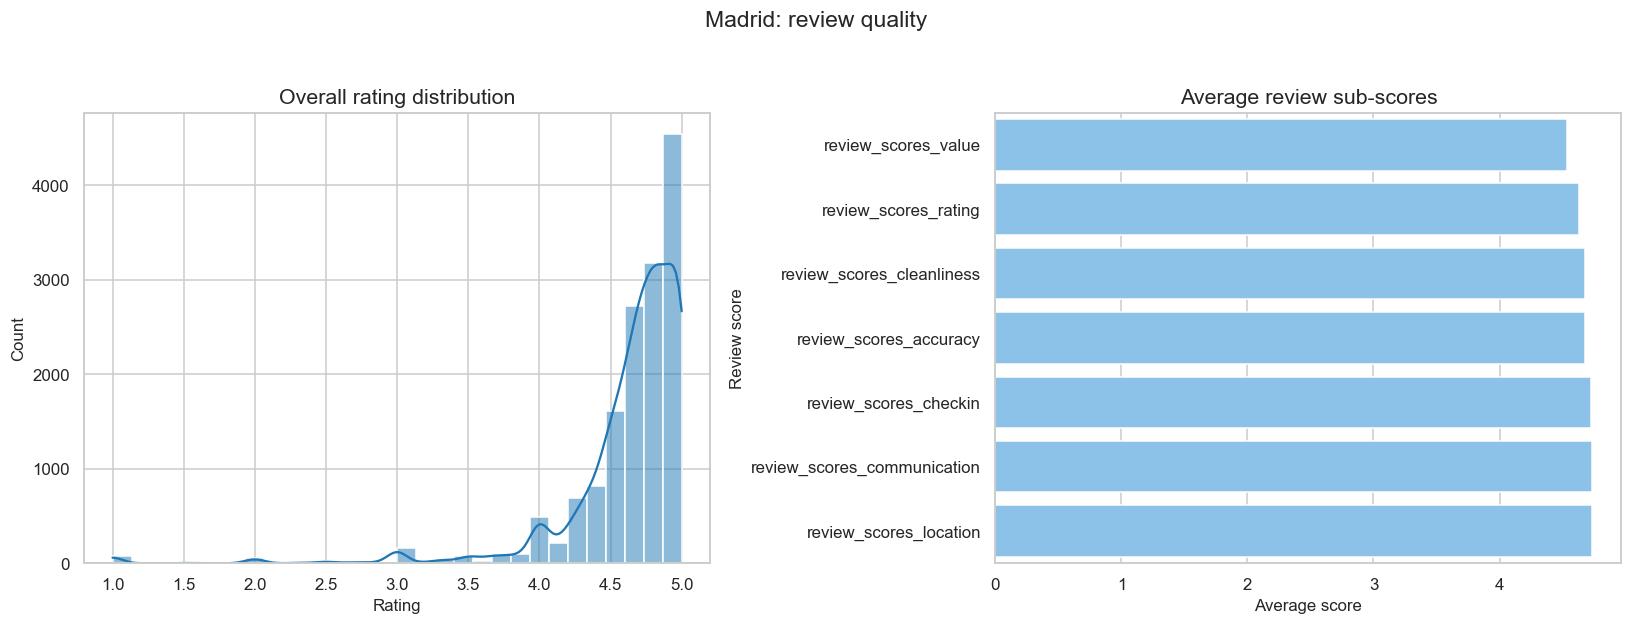

,count,mean,std,min,25%,50%,75%,max
number_of_reviews,17770.0,60.46,104.60,0.00,2.00,18.00,70.0,1184.00
number_of_reviews_ltm,17770.0,18.04,24.76,0.00,1.00,7.00,27.0,590.00
reviews_per_month,14945.0,2.07,2.10,0.01,0.54,1.42,3.0,51.26
days_since_last_review,14945.0,119.40,276.67,0.00,13.00,28.00,85.0,3471.00
raw_review_total_reviews,14945.0,71.89,110.39,1.00,7.00,29.00,88.0,1184.00
raw_reviews_last_6m,14945.0,11.64,13.88,0.00,2.00,7.00,18.0,339.00


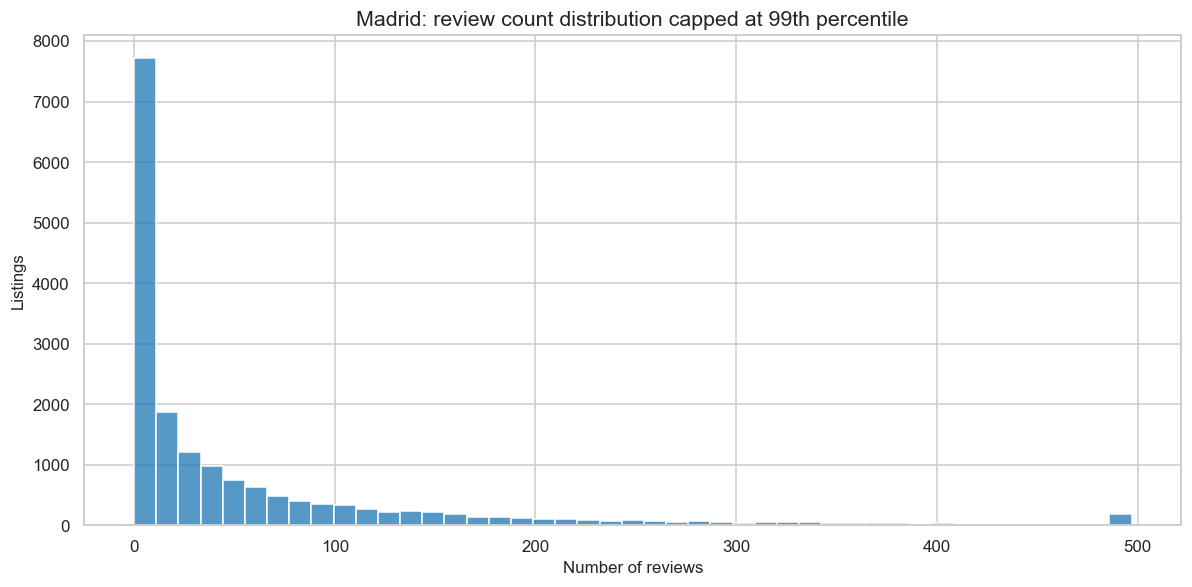

In [13]:
rating_cols = available_columns(
    df,
    [
        "review_scores_rating",
        "review_scores_accuracy",
        "review_scores_cleanliness",
        "review_scores_checkin",
        "review_scores_communication",
        "review_scores_location",
        "review_scores_value",
    ],
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

if "review_scores_rating" in df.columns:
    ratings = as_numeric(df, "review_scores_rating").dropna()
    sns.histplot(ratings, bins=30, kde=True, color=CITY_COLOR, ax=axes[0])
    axes[0].set_title("Overall rating distribution")
    axes[0].set_xlabel("Rating")
else:
    axes[0].axis("off")

if rating_cols:
    rating_means = df[rating_cols].apply(pd.to_numeric, errors="coerce").mean().sort_values()
    sns.barplot(x=rating_means.values, y=rating_means.index, color="#7cc4f8", ax=axes[1])
    axes[1].set_title("Average review sub-scores")
    axes[1].set_xlabel("Average score")
    axes[1].set_ylabel("Review score")
else:
    axes[1].axis("off")

plt.suptitle(f"{CITY}: review quality", y=1.03, fontsize=15)
plt.tight_layout()
plt.show()

review_volume_cols = available_columns(df, ["number_of_reviews", "number_of_reviews_ltm", "reviews_per_month", "days_since_last_review", "raw_review_total_reviews", "raw_reviews_last_6m"])
if review_volume_cols:
    display(df[review_volume_cols].apply(pd.to_numeric, errors="coerce").describe().T.round(2))

    review_count = as_numeric(df, "number_of_reviews")
    plt.figure(figsize=(11, 5.5))
    sns.histplot(review_count.clip(upper=review_count.quantile(0.99)).dropna(), bins=45, color=CITY_COLOR)
    plt.title(f"{CITY}: review count distribution capped at 99th percentile")
    plt.xlabel("Number of reviews")
    plt.ylabel("Listings")
    plt.tight_layout()
    plt.show()
else:
    print("Review volume columns were not found.")

This section examines overall review ratings, review sub-scores, and review volume indicators from the master dataset.

## 12. Correlation With Price

,correlation_with_price
accommodates,0.572
bedrooms,0.370
beds,0.355
has_air_conditioning,0.328
has_tv,0.294
instant_bookable,0.271
host_acceptance_rate,0.266
distance_to_center_km,-0.265
has_heating,0.237
has_elevator,0.229


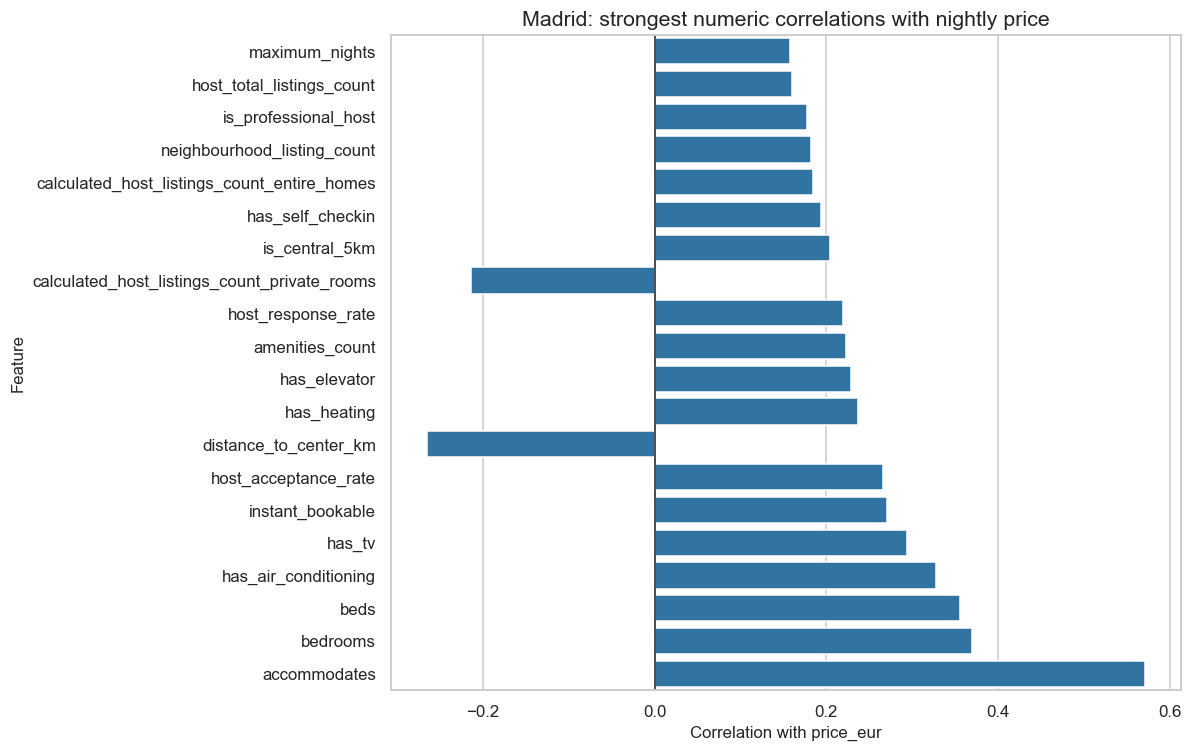

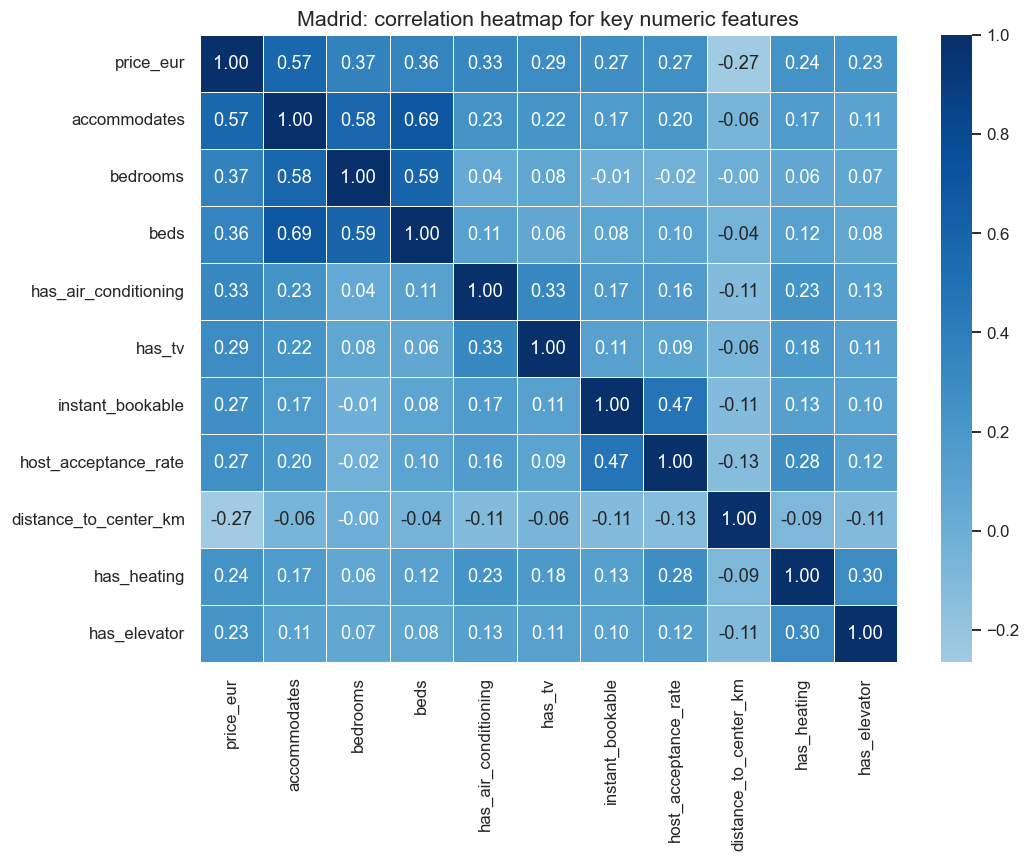

In [14]:
numeric_df = df.select_dtypes(include=[np.number]).copy()

if "price_eur" not in numeric_df.columns:
    raise ValueError("price_eur is needed for the price correlation analysis.")

# Exclude log_price_eur here because it is a transformed version of the same target.
# Keeping it in this EDA chart makes the relationship look artificially dominant.
redundant_target_columns = ["price_eur", "log_price_eur"]
price_correlation_source = numeric_df.drop(
    columns=[column for column in redundant_target_columns if column != "price_eur" and column in numeric_df.columns]
)

price_correlations = (
    price_correlation_source.corr(numeric_only=True)["price_eur"]
    .drop("price_eur")
    .dropna()
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .rename("correlation_with_price")
    .to_frame()
)

display(price_correlations.head(20).round(3))

plt.figure(figsize=(11, 7))
top_corr = price_correlations.head(20).iloc[::-1]
sns.barplot(x=top_corr["correlation_with_price"], y=top_corr.index, color=CITY_COLOR)
plt.axvline(0, color="#222222", linewidth=1)
plt.title(f"{CITY}: strongest numeric correlations with nightly price")
plt.xlabel("Correlation with price_eur")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

heatmap_cols = ["price_eur"] + price_correlations.head(10).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(price_correlation_source[heatmap_cols].corr(), cmap="Blues", center=0, annot=True, fmt=".2f", linewidths=0.4)
plt.title(f"{CITY}: correlation heatmap for key numeric features")
plt.tight_layout()
plt.show()

This identifies which numeric features move most strongly with nightly price. `log_price_eur` is excluded from this chart because it is a transformed version of `price_eur`, so including both would duplicate the target signal.

## 13. Key Findings

In [15]:
price = as_numeric(df, "price_eur")
findings = []
findings.append(f"Dataset size: {len(df):,} listings and {df.shape[1]:,} columns.")
findings.append(f"Median nightly price: {format_eur(price.median())}; mean nightly price: {format_eur(price.mean())}.")

if "room_type" in df.columns:
    top_room = df["room_type"].value_counts().idxmax()
    top_room_share = df["room_type"].value_counts(normalize=True).max() * 100
    findings.append(f"Most common room type: {top_room} ({top_room_share:.1f}% of listings).")

if "neighbourhood_cleansed" in df.columns:
    top_area = df["neighbourhood_cleansed"].value_counts().idxmax()
    findings.append(f"Largest neighbourhood by listing count: {top_area}.")

if "distance_to_center_km" in df.columns:
    findings.append(f"Median distance to centre: {as_numeric(df, 'distance_to_center_km').median():.2f} km.")

if "review_scores_rating" in df.columns:
    findings.append(f"Average review rating: {as_numeric(df, 'review_scores_rating').mean():.2f}.")

if "availability_30" in df.columns:
    findings.append(f"Median availability in the next 30 days: {as_numeric(df, 'availability_30').median():.0f} days.")

print(f"Key EDA findings for {CITY}")
print("=" * (22 + len(CITY)))
for finding in findings:
    print(f"- {finding}")

Key EDA findings for Madrid
- Dataset size: 17,770 listings and 88 columns.
- Median nightly price: EUR 105; mean nightly price: EUR 115.
- Most common room type: Entire home/apt (71.1% of listings).
- Largest neighbourhood by listing count: Embajadores.
- Median distance to centre: 1.96 km.
- Average review rating: 4.63.
- Median availability in the next 30 days: 6 days.
